<a href="https://colab.research.google.com/github/steevansan/codveda/blob/askeytech/Support_Vector_Machine_(SVM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Machine (SVM) for Classification
Description: Implement a Support Vector Machine (SVM) model for binary classification.
Objectives:
Train an SVM model on a labeled dataset. Use different kernels (linear, RBF) and compare performance. Visualize the decision boundary. Evaluate the model using accuracy, precision, recall, and AUC. Tools: Python, scikit-learn, pandas, matplotlib

**Import Required Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           roc_auc_score, confusion_matrix, RocCurveDisplay,
                           PrecisionRecallDisplay)

**Load and Prepare the Data**

In [ ]:
# Load dataset
url = "https://raw.githubusercontent.com/steevansan/codveda/ba120017af239065e0db74aa3cb35f53a8f215cf/1)%20iris.csv"
data = pd.read_csv(url)

# Filter for binary classification (setosa vs versicolor)
binary_data = data[data['species'].isin(['setosa', 'versicolor'])]

# Select features and target
X = binary_data[['sepal_length', 'sepal_width']]  # Using 2 features for visualization
y = binary_data['species'].map({'setosa': 0, 'versicolor': 1})  # Binary encoding

**Split Data into Train/Test Sets**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

**Feature Scaling**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**SVM Model Training Function**

In [ ]:
def train_svm(kernel_type, X_train, y_train, X_test, y_test):
    # Initialize model
    if kernel_type == 'linear':
        model = svm.SVC(kernel='linear', probability=True, random_state=42)
    elif kernel_type == 'rbf':
        model = svm.SVC(kernel='rbf', gamma='scale', probability=True, random_state=42)

    # Train model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return model, y_pred, y_prob

**Evaluate Model Performance**

In [ ]:
def evaluate_model(y_true, y_pred, y_prob, kernel_name):
    # Calculate metrics
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'AUC': roc_auc_score(y_true, y_prob)
    }

    # Print metrics
    print(f"\n{kernel_name} Kernel Performance:")
    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix ({kernel_name} kernel)')
    plt.colorbar()
    plt.xticks([0, 1], ['setosa', 'versicolor'])
    plt.yticks([0, 1], ['setosa', 'versicolor'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # Add numbers to confusion matrix
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]),
                    horizontalalignment='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.show()

    return metrics

**Visualization Functions**

In [ ]:
def plot_roc_pr_curves(model, X_test, y_test, kernel_name):
    # ROC Curve
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f'ROC Curve ({kernel_name} kernel)')
    plt.show()

    # Precision-Recall Curve
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    plt.title(f'Precision-Recall Curve ({kernel_name} kernel)')
    plt.show()

def plot_decision_boundary(model, X, y, kernel_name):
    # Create mesh grid
    h = 0.02  # step size
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict for mesh points
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.xlabel('Sepal Length (standardized)')
    plt.ylabel('Sepal Width (standardized)')
    plt.title(f'Decision Boundary ({kernel_name} kernel)')
    plt.show()

**Main Execution**


Linear Kernel Performance:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
AUC: 1.0000


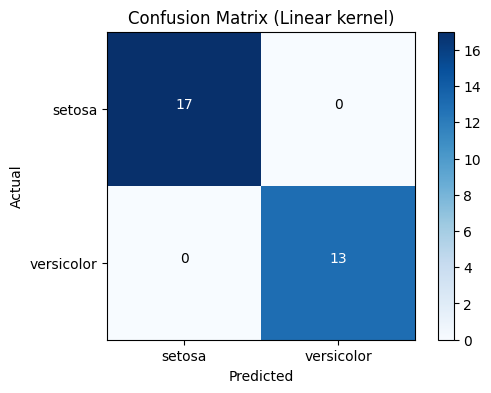

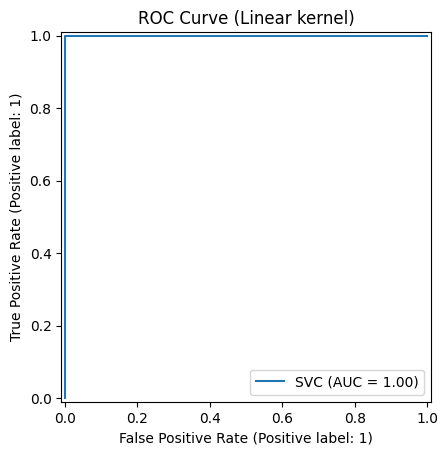

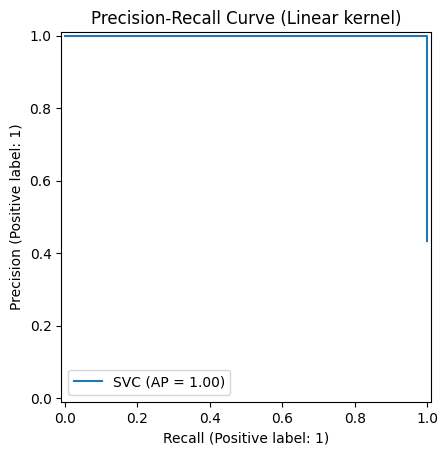

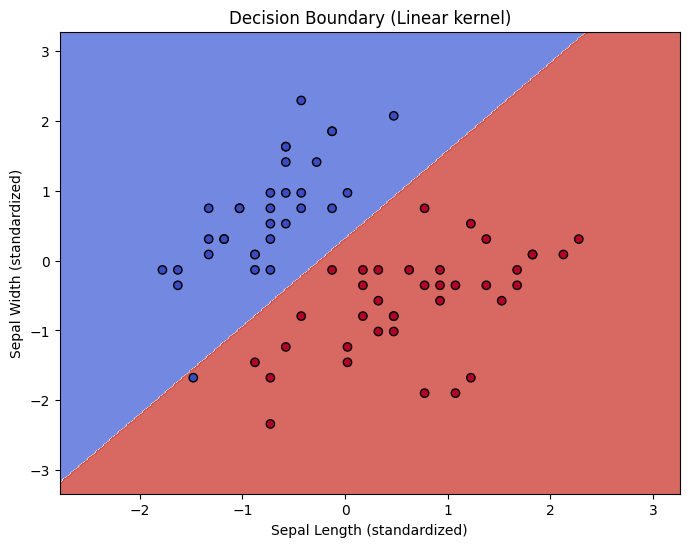


RBF Kernel Performance:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
AUC: 1.0000


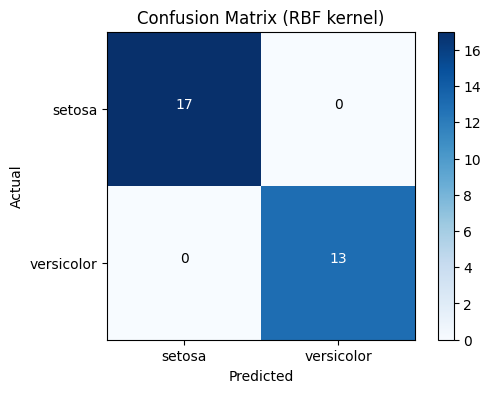

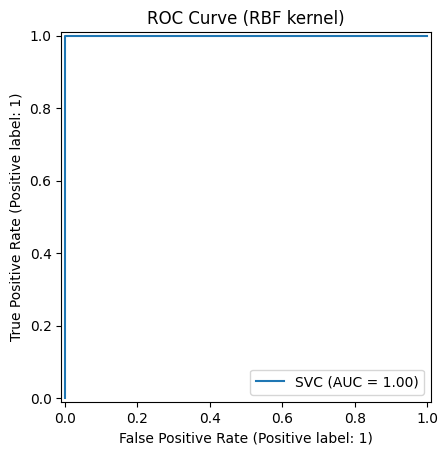

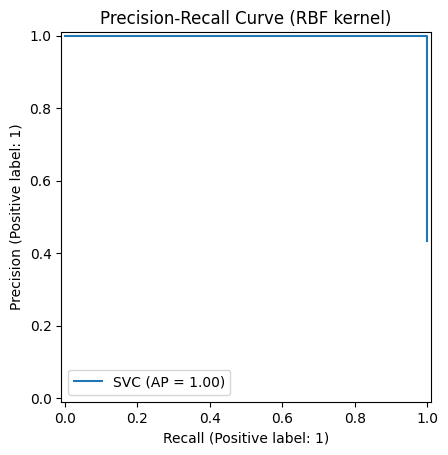

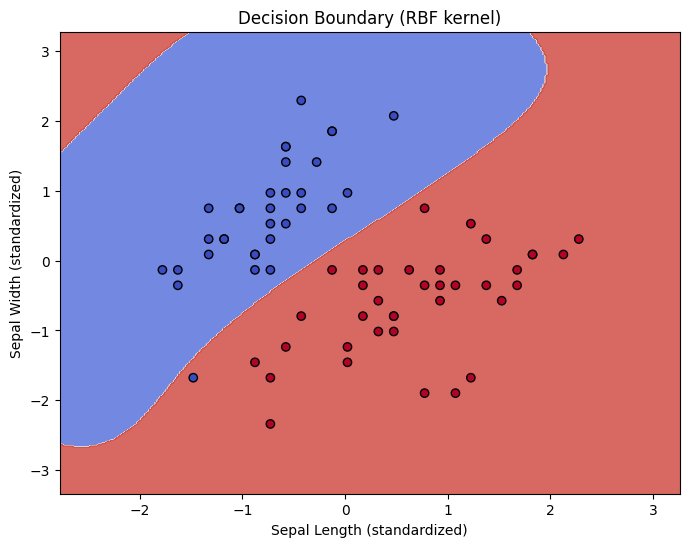


Model Comparison:
           Linear  RBF
Accuracy      1.0  1.0
Precision     1.0  1.0
Recall        1.0  1.0
AUC           1.0  1.0


In [ ]:
# Train and evaluate linear SVM
linear_model, linear_pred, linear_prob = train_svm(
    'linear', X_train_scaled, y_train, X_test_scaled, y_test
)
linear_metrics = evaluate_model(y_test, linear_pred, linear_prob, 'Linear')
plot_roc_pr_curves(linear_model, X_test_scaled, y_test, 'Linear')
plot_decision_boundary(linear_model, X_train_scaled, y_train, 'Linear')

# Train and evaluate RBF SVM
rbf_model, rbf_pred, rbf_prob = train_svm(
    'rbf', X_train_scaled, y_train, X_test_scaled, y_test
)
rbf_metrics = evaluate_model(y_test, rbf_pred, rbf_prob, 'RBF')
plot_roc_pr_curves(rbf_model, X_test_scaled, y_test, 'RBF')
plot_decision_boundary(rbf_model, X_train_scaled, y_train, 'RBF')

# Compare performance
print("\nModel Comparison:")
comparison = pd.DataFrame({'Linear': linear_metrics, 'RBF': rbf_metrics})
print(comparison)